
 # Synthetic temporal network with community structure
====================================================

This example uses :class:`tempnet.synth_temp_network.SynthTempNetwork` to
generate a synthetic continuous-time temporal network of 12 agents organised
into three communities of four.  Within-community contacts are more frequent
than cross-community ones (block probability structure).

The simulation produces a stream of time-stamped contact events that are
then loaded into a :class:`tempnet.ContTempNetwork` for analysis.

Two plots are produced:

1. **Contact timeline** — each contact is drawn as a horizontal bar coloured
   by community membership of the source node.
2. **Event-duration distribution** — histogram of all contact durations.

In [ ]:
!pip install -e "C:/Users/Yasaman/TEMPORAL-NETWORKS"
!pip install -e ../..
!pip uninstall -y tempnet


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tempnet import ContTempNetwork
from tempnet.synth_temp_network import Individual, SynthTempNetwork, make_step_block_probs
rng = np.random.default_rng(42)

In [3]:
# Create 12 :class:`~tempnet.synth_temp_network.Individual` agents split into
# three equal communities (groups 0, 1, 2).  Interaction durations are drawn
# from an exponential distribution with mean ``inter_tau``; inter-activation
# waiting times use mean ``activ_tau``.



N_GROUPS = 3
N_PER_GROUP = 4
inter_tau = 1.0   # mean contact duration
activ_tau = 5.0   # mean inter-activation time

Individual.all_IDs = []    # reset class-level state between runs
Individual.all_groups = []

individuals = [
    Individual(
        ID=g * N_PER_GROUP + i,
        inter_distro_scale=inter_tau,
        activ_distro_scale=activ_tau,
        group=g,
    )
    for g in range(N_GROUPS)
    for i in range(N_PER_GROUP)
]

In [4]:


# %%
# Block-probability modulation
# ----------------------------
# ``make_step_block_probs`` returns a time-dependent function that cycles
# through phases where different community pairs are highlighted.

m1 = 0.8   # within-community interaction probability
p1 = 0.8   # cross-community interaction probability (for the active pair)

block_prob_mod_func = make_step_block_probs(
    deltat1=40 * activ_tau,
    deltat2=(9 / 2 * m1 - 3 / 2) * 40 * activ_tau / (2 * p1 - 1),
    m1=m1,
    p1=p1,
)
t_end = 3 * (40 * activ_tau + (9 / 2 * m1 - 3 / 2) * 40 * activ_tau / (2 * p1 - 1))




In [5]:
# %%
# Run the simulation
# ------------------

sim = SynthTempNetwork(
    individuals=individuals,
    t_start=0,
    t_end=t_end,
    next_event_method='block_probs_mod',
    block_prob_mod_func=block_prob_mod_func,
)
sim.run()

print(
    f"Simulation produced {len(sim.indiv_sources)} contact events "
    f"over t ∈ [0, {t_end:.1f}]."
)


Simulation produced 4848 contact events over t ∈ [0, 2700.0].


In [6]:

# %%
# Build a ContTempNetwork
# -----------------------

network = ContTempNetwork(
    source_nodes=sim.indiv_sources,
    target_nodes=sim.indiv_targets,
    starting_times=sim.start_times,
    ending_times=sim.end_times,
)

print(f"Nodes : {network.nodes}")
print(f"Events: {len(network.events_table)}")


Nodes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Events: 4848


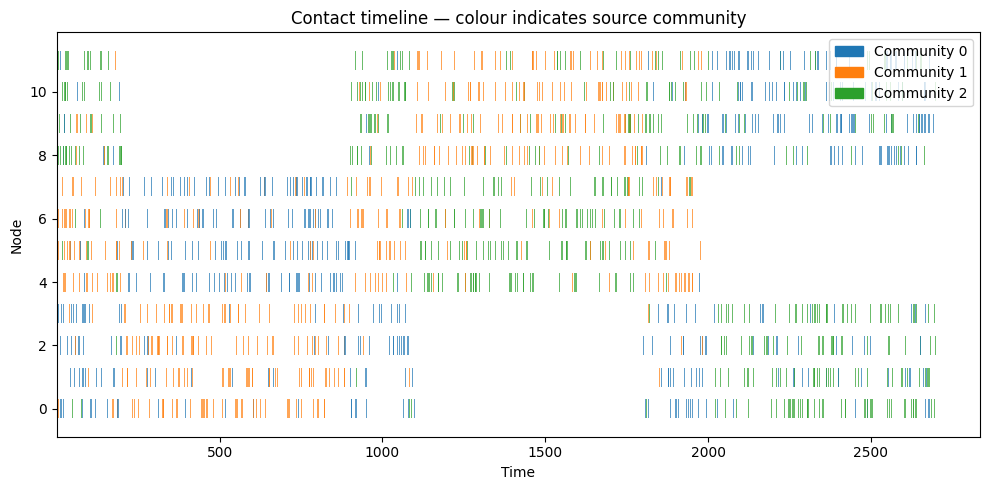

In [7]:
# %%
# Plot 1: Contact timeline
# ------------------------
# Each row is a node; each bar represents a contact coloured by the source
# node's community.

GROUP_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']  # one colour per group
node_to_group = {
    g * N_PER_GROUP + i: g
    for g in range(N_GROUPS)
    for i in range(N_PER_GROUP)
}

fig, ax = plt.subplots(figsize=(10, 5))

et = network.events_table
for _, row in et.iterrows():
    src = int(row[ContTempNetwork._SOURCES])
    tgt = int(row[ContTempNetwork._TARGETS])
    t0 = row[ContTempNetwork._STARTS]
    t1 = row[ContTempNetwork._ENDINGS]
    color = GROUP_COLORS[node_to_group[src]]
    ax.barh(tgt, t1 - t0, left=t0, height=0.6, color=color, alpha=0.7)

ax.set_xlabel('Time')
ax.set_ylabel('Node')
ax.set_title('Contact timeline — colour indicates source community')

handles = [
    plt.Rectangle((0, 0), 1, 1, color=GROUP_COLORS[g], label=f'Community {g}')
    for g in range(N_GROUPS)
]
ax.legend(handles=handles, loc='upper right')
plt.tight_layout()
plt.show()

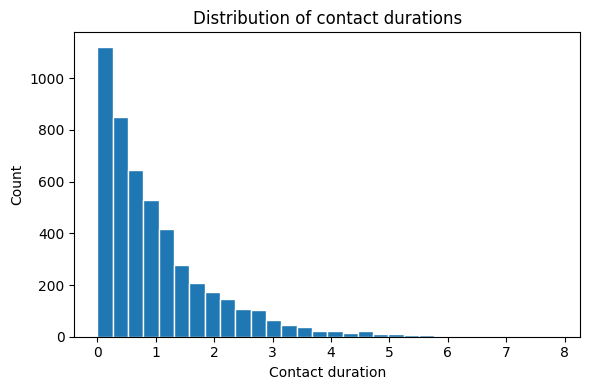

In [8]:


# %%
# Plot 2: Event-duration distribution
# ------------------------------------

durations = (
    et[ContTempNetwork._ENDINGS] - et[ContTempNetwork._STARTS]
).values

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(durations, bins=30, edgecolor='white')
ax.set_xlabel('Contact duration')
ax.set_ylabel('Count')
ax.set_title('Distribution of contact durations')
plt.tight_layout()
plt.show()
